# Week 3: Priority / Urgency Classification Model
## AI-Driven Citizen Grievance & Sentiment Analysis System

### Objective
Build a machine learning model that predicts the urgency / priority level of a citizen complaint.

### Priority Labels
- Low
- Medium
- High
- Critical

In [23]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [24]:
df = pd.read_csv("../data/final_cleaned_grievances.csv")
df.head()

,Complaint Type,Descriptor,Agency,Agency Name,text,clean_text
0,Street Condition,Pothole,DOT,Department of Transportation,Street Condition Pothole,street condition pothole
1,Noise - Commercial,Loud Music/Party,NYPD,New York City Police Department,Noise - Commercial Loud Music/Party,noise commercial loud musicparty
2,Noise - Residential,Loud Music/Party,NYPD,New York City Police Department,Noise - Residential Loud Music/Party,noise residential loud musicparty
3,Noise - Residential,Loud Music/Party,NYPD,New York City Police Department,Noise - Residential Loud Music/Party,noise residential loud musicparty
4,Illegal Parking,Commercial Overnight Parking,NYPD,New York City Police Department,Illegal Parking Commercial Overnight Parking,illegal parking commercial overnight parking


In [ ]:
print("Dataset shape:", df.shape)


Dataset shape: (49980, 6)


In [26]:
print(df.columns)

Index(['Complaint Type', 'Descriptor', 'Agency', 'Agency Name', 'text',
       'clean_text'],
      dtype='object')


Step 1: Create Priority Labels

In [44]:
def predict_priority_from_text(text):
    text = str(text).lower()

    # Critical
    critical_keywords = [
        "no electricity", "power outage", "no power",
        "no heat", "no water", "gas leak", "fire", "smoke",
        "flood", "flooding", "sewer backup", "urgent", "emergency"
    ]

    # High
    high_keywords = [
        "water leakage", "water leak", "leakage", "ceiling leak",
        "street light", "traffic signal", "pothole",
        "electric issue", "electric problem", "rodent"
    ]

    # Medium
    medium_keywords = [
        "garbage", "missed collection", "noise",
        "illegal parking", "dirty", "unsanitary", "sanitation"
    ]

    if any(word in text for word in critical_keywords):
        return "Critical"
    elif any(word in text for word in high_keywords):
        return "High"
    elif any(word in text for word in medium_keywords):
        return "Medium"
    else:
        return "Low"

In [45]:
# Apply Priority Label Function
df['priority_label'] = df.apply(assign_priority, axis=1)
df[['Complaint Type', 'Descriptor', 'text', 'priority_label']].head(10)

,Complaint Type,Descriptor,text,priority_label
0,Street Condition,Pothole,Street Condition Pothole,High
1,Noise - Commercial,Loud Music/Party,Noise - Commercial Loud Music/Party,Medium
2,Noise - Residential,Loud Music/Party,Noise - Residential Loud Music/Party,Medium
3,Noise - Residential,Loud Music/Party,Noise - Residential Loud Music/Party,Medium
4,Illegal Parking,Commercial Overnight Parking,Illegal Parking Commercial Overnight Parking,Medium
5,Noise - Residential,Loud Music/Party,Noise - Residential Loud Music/Party,Medium
6,Noise - Residential,Banging/Pounding,Noise - Residential Banging/Pounding,Medium
7,Noise - Commercial,Loud Music/Party,Noise - Commercial Loud Music/Party,Medium
8,Taxi Complaint,Driver Complaint - Non Passenger,Taxi Complaint Driver Complaint - Non Passenger,Low
9,Noise - Residential,Loud Music/Party,Noise - Residential Loud Music/Party,Medium


In [46]:
#Check Priority Distribution
print(df['priority_label'].value_counts())

priority_label
Medium      19682
Low         17977
Critical     8486
High         3835
Name: count, dtype: int64


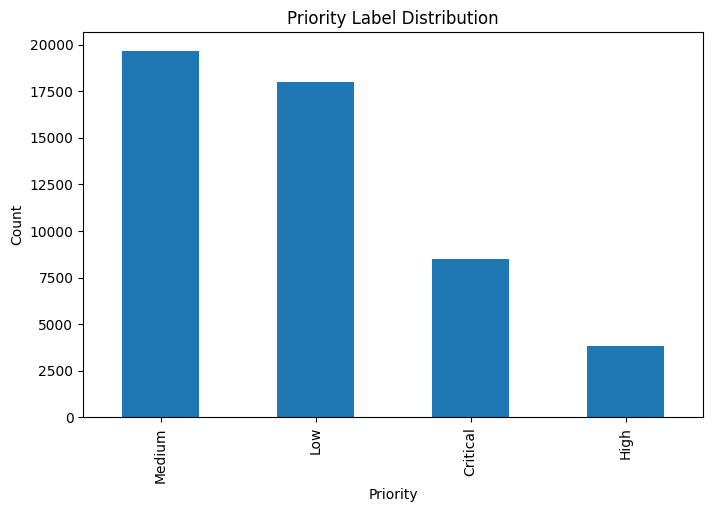

In [47]:
#Plot Priority Distribution
df['priority_label'].value_counts().plot(kind='bar', figsize=(8,5))
plt.title("Priority Label Distribution")
plt.xlabel("Priority")
plt.ylabel("Count")
plt.show()

Step 2: Prepare Features and Labels

In [48]:
#Features and Target
X = df['clean_text']
y = df['priority_label']

print("Number of samples:", len(X))

Number of samples: 49980


In [49]:
vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = vectorizer.fit_transform(X)

print("TF-IDF shape:", X_tfidf.shape)

TF-IDF shape: (49980, 840)


Step 3: Train-Test Split


In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 39984
Testing samples: 9996


Step 4: Train Priority Classification Model

In [51]:
priority_model = LogisticRegression(max_iter=1000)
priority_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Step 5: Prediction and Evaluation

In [52]:
#predict
y_pred = priority_model.predict(X_test)

In [53]:
accuracy = accuracy_score(y_test, y_pred)
print("Priority Model Accuracy:", accuracy)

Priority Model Accuracy: 0.9995998399359743


In [54]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

    Critical       1.00      1.00      1.00      1697
        High       1.00      1.00      1.00       767
         Low       1.00      1.00      1.00      3595
      Medium       1.00      1.00      1.00      3937

    accuracy                           1.00      9996
   macro avg       1.00      1.00      1.00      9996
weighted avg       1.00      1.00      1.00      9996



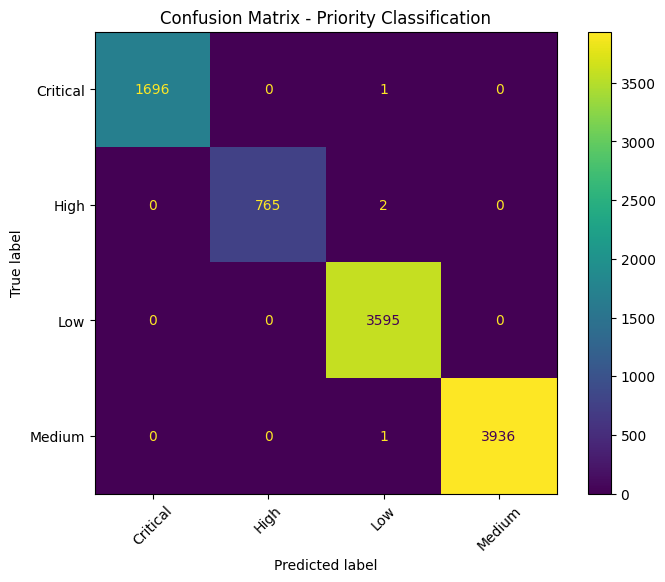

In [55]:
cm = confusion_matrix(y_test, y_pred, labels=priority_model.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=priority_model.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix - Priority Classification")
plt.show()

Step 6: Test with Custom Complaints

In [56]:
sample_complaints = [
    "No electricity in my building for 2 days",
    "Garbage has not been collected from my street",
    "Loud music coming from neighbor house at night",
    "Street light is not working near my home",
    "Water leakage from ceiling in apartment"
]

for complaint in sample_complaints:
    pred = predict_priority_from_text(complaint)
    print(f"Complaint: {complaint}")
    print(f"Predicted Priority: {pred}")
    print("-" * 50)

Complaint: No electricity in my building for 2 days
Predicted Priority: Critical
--------------------------------------------------
Complaint: Garbage has not been collected from my street
Predicted Priority: Medium
--------------------------------------------------
Complaint: Loud music coming from neighbor house at night
Predicted Priority: Low
--------------------------------------------------
Complaint: Street light is not working near my home
Predicted Priority: High
--------------------------------------------------
Complaint: Water leakage from ceiling in apartment
Predicted Priority: High
--------------------------------------------------


Step 7: Save Model and Vectorizer

In [57]:
joblib.dump(priority_model, "../models/priority_model.pkl")
joblib.dump(vectorizer, "../models/priority_vectorizer.pkl")

print("Priority model and vectorizer saved successfully!")

Priority model and vectorizer saved successfully!
